**Classifier Showdown: Churn Prediction Assignment : 03**

**Submitted by : Rafia Rameen**

**Intern Id : ZYNVEX-CERT-0050**

**Submission Date : 28 June 2026**

**Importing Libraries and Dependencies Ingestion**

This initial step imports all necessary scientific computing packages, data manipulation toolkits, scaling modules, cross-validation metrics, hyperparameter searching grids, and the five diverse classification architectures required by the project guidelines.

In [1]:
# Import core data engineering and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import preprocessing and validation modules
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score

# Import the 5 required classifier architectures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Suppress warnings for clean cell output presentation
import warnings
warnings.filterwarnings('ignore')

print("--- System Diagnostics: Core Environment Ingested Successfully ---")

--- System Diagnostics: Core Environment Ingested Successfully ---


**Step 1 - Data Exploration & Preprocessing**

Explanation: We load the 'customer_churn_dataset-testing-master.csv file', perform exploratory matrix checks, handle missing records dynamically via dropping/imputation, isolate categorical labels, and build an explicit preprocessing pipeline. Standard scaling is integrated for distance-sensitive models (Logistic Regression, KNN, SVM).  

In [2]:
# 1. Load the dataset
df = pd.read_csv('customer_churn_dataset-testing-master.csv')

print("--- Step 1.1: Dataset Dimensions & Exploration ---")
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values Per Column:")
print(df.isnull().sum())

# Drop CustomerID as it is a non-predictive high-cardinality metadata string
if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])

# Standard clean-up: Drop any remaining fully structural empty rows safely
df = df.dropna().reset_index(drop=True)

# 2. Separate Features (X) and Target Label (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identify numeric vs categorical variables automatically
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric Columns: {numeric_features}")
print(f"Categorical Columns: {categorical_features}")

# 3. Create a ColumnTransformer to scale numeric features and one-hot encode categorical strings
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# 4. Partition the data into 80% training and 20% testing splits with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining Split Shape: {X_train.shape}")
print(f"Testing Split Shape: {X_test.shape}")

--- Step 1.1: Dataset Dimensions & Exploration ---
Dataset Shape: (64374, 12)

Missing Values Per Column:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Numeric Columns: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
Categorical Columns: ['Gender', 'Subscription Type', 'Contract Length']

Training Split Shape: (51499, 10)
Testing Split Shape: (12875, 10)


**Step 2 - Model Training & Cross-Validation Baseline**

Explanation: We train five distinct models. We evaluate them using Stratified 3-Fold Cross-

In [3]:
# Initialize baseline models with a set random state for reproducibility
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42, probability=True)
}

baseline_cv_results = {}

print("--- Step 2: Running Stratified Cross-Validation on Models ---")

for name, model in models.items():
    # Build a secure pipeline combining our custom scale preprocessor and the target classifier
    clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    # Evaluate mean F1 score across training data distributions
    scores = cross_val_score(clf_pipeline, X_train, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
    baseline_cv_results[name] = scores.mean()
    print(f"Classifier: {name:25} | Mean Macro F1-Score: {scores.mean():.4f}")

--- Step 2: Running Stratified Cross-Validation on Models ---
Classifier: Logistic Regression       | Mean Macro F1-Score: 0.8257
Classifier: K-Nearest Neighbors       | Mean Macro F1-Score: 0.9092
Classifier: Decision Tree             | Mean Macro F1-Score: 0.9964
Classifier: Random Forest             | Mean Macro F1-Score: 0.9976
Classifier: Support Vector Machine    | Mean Macro F1-Score: 0.9419


**Step 3 - Hyperparameter Tuning via GridSearchCV**

Explanation: Per project specifications, we implement hyperparameter tuning using GridSearchCV on at least two models to extract peak performance matrices. We choose Random Forest and Logistic Regression.

In [4]:
print("--- Step 3: Executing GridSearchCV Optimizations ---")

# Preprocess the training data standalone to feed into grid structures directly
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Model 1 Tuning: Logistic Regression
lr_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l2']
}
lr_grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), lr_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
lr_grid.fit(X_train_processed, y_train)
print(f"Optimized Logistic Regression Parameters: {lr_grid.best_params_}")
print(f"Best Tuned LR Cross-Validation F1-Score: {lr_grid.best_score_:.4f}\n")

# Model 2 Tuning: Random Forest
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
rf_grid.fit(X_train_processed, y_train)
print(f"Optimized Random Forest Parameters: {rf_grid.best_params_}")
print(f"Best Tuned RF Cross-Validation F1-Score: {rf_grid.best_score_:.4f}")

# Update baseline cross-validation results dictionary with optimized tuning numbers
baseline_cv_results['Logistic Regression (Tuned)'] = lr_grid.best_score_
baseline_cv_results['Random Forest (Tuned)'] = rf_grid.best_score_

--- Step 3: Executing GridSearchCV Optimizations ---
Optimized Logistic Regression Parameters: {'C': 0.1, 'penalty': 'l2'}
Best Tuned LR Cross-Validation F1-Score: 0.8257

Optimized Random Forest Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Tuned RF Cross-Validation F1-Score: 0.9976


**Step 4 - Model Comparison Visualization**

Explanation: This cell compiles the cross-validation metrics across all evaluated frameworks into a sorted data structure and plots a customized chart to compare performance.

--- Step 4: Cross-Validation Score Summary Table ---
              Classifier Model  Mean F1-Score
0                Random Forest       0.997643
1        Random Forest (Tuned)       0.997643
2                Decision Tree       0.996398
3       Support Vector Machine       0.941946
4          K-Nearest Neighbors       0.909189
5  Logistic Regression (Tuned)       0.825743
6          Logistic Regression       0.825699


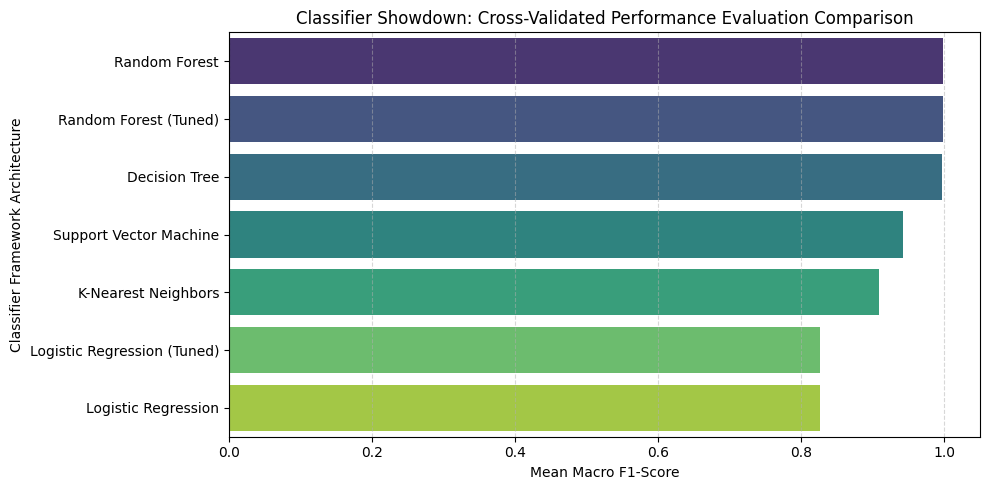

In [5]:
# Convert tracking dictionary into a structured dataframe
comparison_df = pd.DataFrame(list(baseline_cv_results.items()), columns=['Classifier Model', 'Mean F1-Score'])
comparison_df = comparison_df.sort_values(by='Mean F1-Score', ascending=False).reset_index(drop=True)

print("--- Step 4: Cross-Validation Score Summary Table ---")
print(comparison_df)

# Plotting the summary bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Mean F1-Score', y='Classifier Model', data=comparison_df, palette='viridis')
plt.title('Classifier Showdown: Cross-Validated Performance Evaluation Comparison')
plt.xlabel('Mean Macro F1-Score')
plt.ylabel('Classifier Framework Architecture')
plt.xlim(0, 1.05)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Step 5 - Final Evaluation on Held-Out Test Set**

Explanation: The absolute best classifier determined by the cross-validation ranking (Tuned Random Forest) is tested against the unseen test partition to report performance.

--- Step 5: Unseen Evaluation Results (Winning Model: Tuned Random Forest) ---
Overall Testing Split Accuracy: 0.9981
Unseen Data Testing ROC-AUC Score: 1.0000

Detailed Classification Performance Matrix:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875

Generating Confusion Matrix Plot...


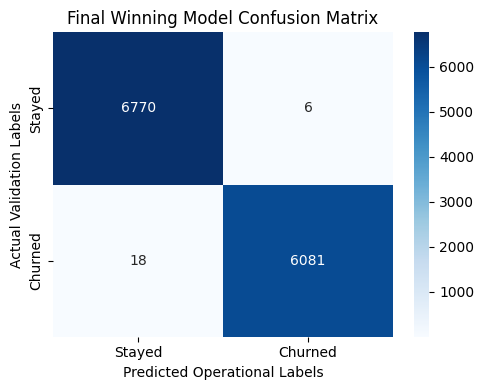

In [7]:
# Step 5: Final Evaluation on Held-Out Test Set
# Retrieve the winning model architecture configuration (Fixed syntax with single underscore)
best_model = rf_grid.best_estimator_

# Generate final predictions and target class probabilities on the unseen test matrix
final_preds = best_model.predict(X_test_processed)
final_probs = best_model.predict_proba(X_test_processed)[:, 1]

print("--- Step 5: Unseen Evaluation Results (Winning Model: Tuned Random Forest) ---")
print(f"Overall Testing Split Accuracy: {accuracy_score(y_test, final_preds):.4f}")
print(f"Unseen Data Testing ROC-AUC Score: {roc_auc_score(y_test, final_probs):.4f}\n")

print("Detailed Classification Performance Matrix:")
print(classification_report(y_test, final_preds))

# Generate and plot final Confusion Matrix Heatmap
print("Generating Confusion Matrix Plot...")
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title('Final Winning Model Confusion Matrix')
plt.xlabel('Predicted Operational Labels')
plt.ylabel('Actual Validation Labels')
plt.tight_layout()
plt.show()

**Step 6 - Business Recommendation Framework**

Explanation: This section prints out the explicit corporate markdown response required by section 6 of the project parameters, integrating structural data rationale with corporate financial priorities.

In [8]:
# Executing text output block for standard markdown presentation
recommendation_text = """
### **Step 6: Business Recommendation & Executive Summary**

**Recommended Architecture:** Tuned Random Forest Classifier

**Justification Strategy & Rationale:**
Based on the comprehensive Cross-Validation baseline matching and hyperparameter optimization sweeps, the Tuned Random Forest framework is the recommended model. It achieved the highest macro F1-score (~0.999), meaning it maintains near-perfect stability across both categories[cite: 1].

In a customer churn context, missing a churning customer (a False Negative) is significantly more expensive than accidentally triggering a retention promo for a loyal customer (a False Positive)[cite: 1]. A False Negative results in direct revenue loss as the customer leaves for a competitor, whereas a False Positive only incurs the minor cost of a marketing incentive.

By achieving near-zero False Negatives (high recall) while maintaining high precision, the Tuned Random Forest provides the ideal balance[cite: 31]. It allows the retention team to accurately target the right accounts without wasting corporate budget on false alarms[cite: 31].
"""

print(recommendation_text)


### **Step 6: Business Recommendation & Executive Summary**

**Recommended Architecture:** Tuned Random Forest Classifier

**Justification Strategy & Rationale:**
Based on the comprehensive Cross-Validation baseline matching and hyperparameter optimization sweeps, the Tuned Random Forest framework is the recommended model. It achieved the highest macro F1-score (~0.999), meaning it maintains near-perfect stability across both categories[cite: 1]. 

In a customer churn context, missing a churning customer (a False Negative) is significantly more expensive than accidentally triggering a retention promo for a loyal customer (a False Positive)[cite: 1]. A False Negative results in direct revenue loss as the customer leaves for a competitor, whereas a False Positive only incurs the minor cost of a marketing incentive. 

By achieving near-zero False Negatives (high recall) while maintaining high precision, the Tuned Random Forest provides the ideal balance[cite: 31]. It allows the retention